# Площадь под графиком и управление порогом

## Цель работы

Научиться применять кривые PR и ROC для оценки моделей классификации, использовать их для выбора оптимального порога классификации

## 1. Генерация датасета и обучение модели

Сгенерируем датасет для бинарной классификации:

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

Обучим модель логистической регрессии:

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

Получим вероятностные предсказания:

In [3]:
y_pred_proba = model.predict_proba(X_test)
y_pred_proba[:5]

array([[0.00402958, 0.99597042],
       [0.00200644, 0.99799356],
       [0.99469656, 0.00530344],
       [0.84790996, 0.15209004],
       [0.00166614, 0.99833386]])

## 2. Построение ROC-кривой

Для построения ROC-кривой используем функцию `roc_curve` из sklearn.metrics:

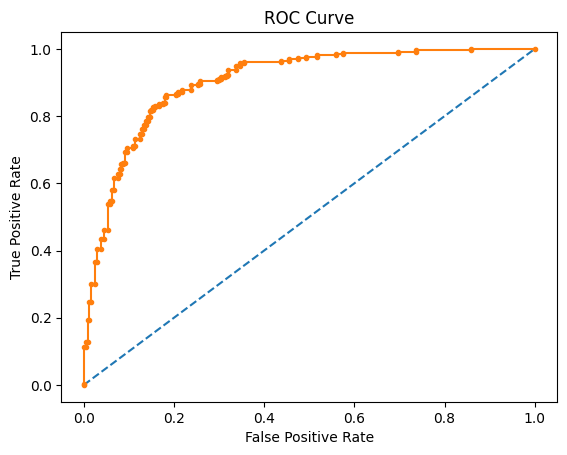

In [4]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

Вычислим ROC-AUC — площадь под ROC-кривой:

In [5]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred_proba[:, 1])

0.9027724358974359

## 3. Построение PR-кривой

Построим кривую Precision-Recall:

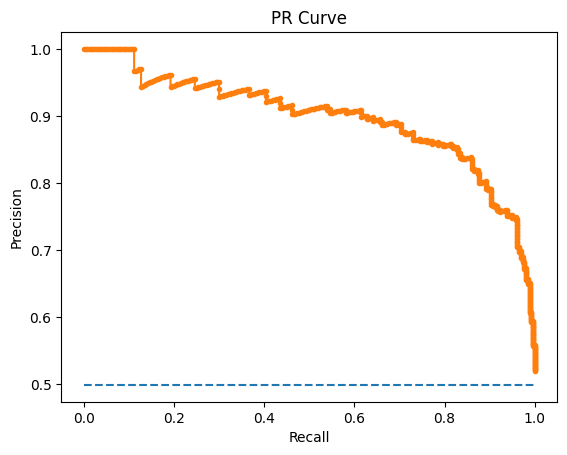

In [6]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve')
plt.show()

Вычислим PR-AUC — площадь под PR-кривой:

In [7]:
auc(recall, precision)

0.897662372903334

Посмотрим на отчёт о классификации при стандартном пороге 0.5:

In [8]:
from sklearn.metrics import classification_report

y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



## 4. Сравнение моделей

Обучим на тех же данных другую модель — метод ближайших соседей:

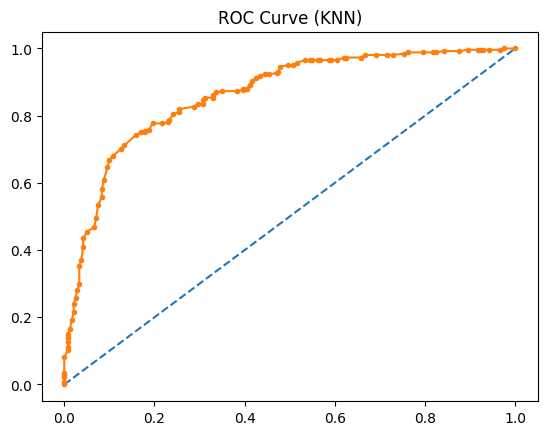

In [9]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('ROC Curve (KNN)')
plt.show()

ROC-AUC второй модели:

In [10]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.8630608974358974

## 5. Дизбаланс классов

Сгенерируем датасет с сильным дизбалансом классов (99% vs 1%):

In [11]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

Проверим распределение классов:

In [12]:
print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=492, Class1=8
Тестовая: Class0=493, Class1=7


Обучим модель логистической регрессии:

In [13]:
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Отчёт о классификации (поведение модели на несбалансированных данных):

In [14]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       493
           1       0.00      0.00      0.00         7

    accuracy                           0.99       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.97      0.99      0.98       500



c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

Построим ROC-кривую для дизбалансированных данных:

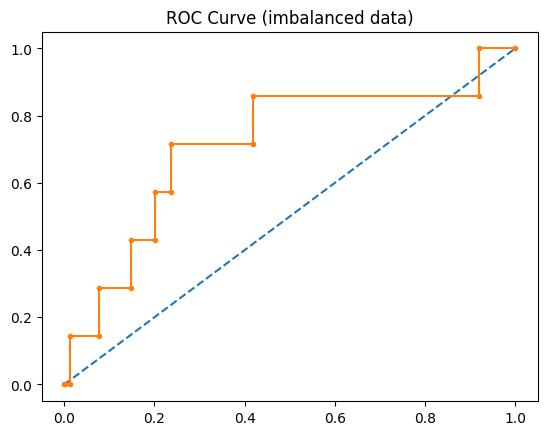

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('ROC Curve (imbalanced data)')
plt.show()

Построим PR-кривую (даёт более реалистичную оценку при дизбалансе):

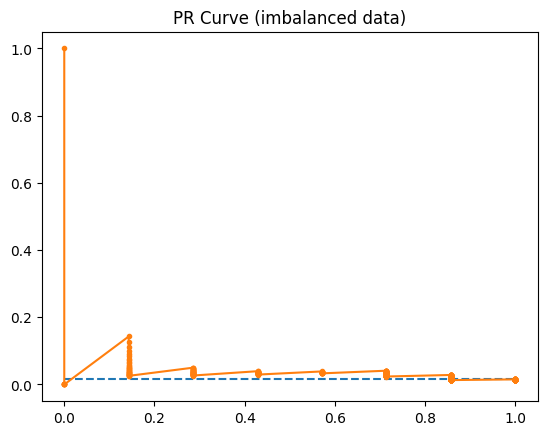

In [16]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.title('PR Curve (imbalanced data)')
plt.show()

## 6. Выбор оптимального порога по кривым

Сгенерируем более крупный датасет с дизбалансом для оптимизации порога:

In [17]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Построим PR-кривую:

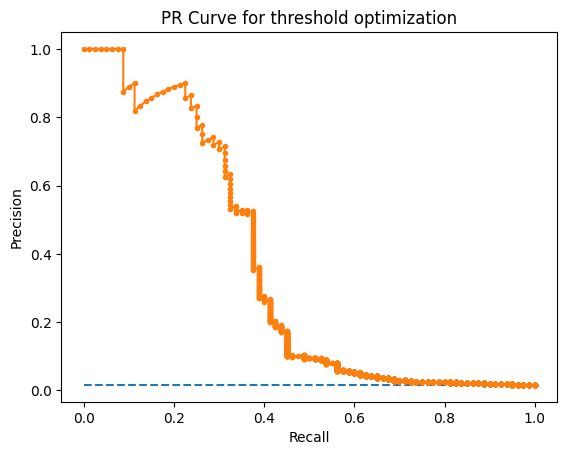

In [18]:
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve for threshold optimization')
plt.show()

Найдём оптимальный порог по метрике F1:

In [19]:
from numpy import argmax

f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.159726, F-Score=0.438


Отобразим оптимальную точку на графике:

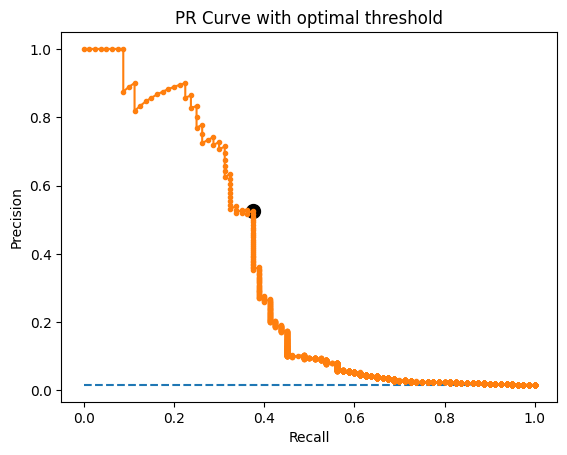

In [20]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black', s=100)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve with optimal threshold')
plt.show()

Применим оптимальный порог для классификации:

In [21]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4920
           1       0.52      0.36      0.43        80

    accuracy                           0.98      5000
   macro avg       0.75      0.68      0.71      5000
weighted avg       0.98      0.98      0.98      5000



Сравним с результатами при пороге по умолчанию (0.5):

In [22]:
y_pred_default = model.predict(X_test)
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.88      0.17      0.29        80

    accuracy                           0.99      5000
   macro avg       0.93      0.59      0.64      5000
weighted avg       0.98      0.99      0.98      5000

